In [20]:
# This notebook is for data exploration of seabird tracks as wells as ocean color data in Google Earth Engine (GEE)

In [2]:
# Imports
import ee
import geemap
import geemap.colormaps as cm
import geedim
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
from shapely.geometry import Point
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt


C:\Users\s44ba\anaconda3_2024\envs\gis5201_project1_GEE\Lib\site-packages\movingpandas\__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [21]:
# Custom import from a different folder
import sys
#sys.path.append('../project')
#import project_functions

In [ ]:
ee.Authenticate()

In [4]:
m1 = geemap.Map()

Enter verification code:  4/1AeoWuM-I6SQxasAzx1XOxRdipf2i0ttnEs-Nd2c9PeJN5wSNImM7UOUOmCE



Successfully saved authorization token.


In [5]:
# ROI
roi = ee.Geometry.BBox(-50.0, 35.0, -10.0, 62.0)
m1.center_object(roi)
m1    

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [6]:
# A function that returns a single ocean color image, given a date
# Caller must fix scale and offset
def single_ocean_color_image(this_timestamp_datetime,roi):
    # Ocean color collection
    collection = (ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
        .filter(ee.Filter.date("2019-02-01","2019-08-01"))
        .select('chlor_a')
        .filter(ee.Filter.bounds(roi))          
    )
    # return first image from the collection, scaled and offset to degrees C
    first_image = collection.first()
    #return first_image.multiply(0.001).add(20.0)
    # For some reason, the caller has trouble with max<min when I include the scaling and offset here;
    # therefore, let the caller apply the scaling and offset in the vis_params
    return first_image

In [7]:
# Use vis params bounds that work for ocean color image
# For single-band images, the palette is used to define how band values get translated into colors
min_val = 0
max_val = 1
vis_params_ocean_color = {
  "min": min_val,
  "max": max_val,
  "palette": ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
}

# Javascript example from https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_MARINE_SATELLITE_OCEAN_COLOR_V6#code-editor-javascript
#var dataset = ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
#                  .filter(ee.Filter.date('2024-06-01', '2024-07-01'));
#var chlorA = dataset.select('chlor_a');
#var chlorAVis = {
#  min: 0,
#  max: 1,
#  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
#};

In [8]:
# Test function before putting it in the loop
this_timestamp_datetime = datetime(2019,2,15)
this_image = single_ocean_color_image(this_timestamp_datetime,roi)

m1.add_layer(this_image, vis_params_ocean_color, "test_ocean_color_image")
m1

Map(bottom=1723.0, center=[48.04870994288686, -31.948242187500004], controls=(WidgetControl(options=['position…

In [9]:
roi


ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -50.0,
              62.0
            ],
            [
              -50.0,
              35.0
            ],
            [
              -10.0,
              35.0
            ],
            [
              -10.0,
              62.0
            ]
          ]
        ]
      },
      "geodesic": {
        "constantValue": false
      }
    }
  }
})

In [10]:
# Load animal track csv into pandas dataframe
input_csv_folder = 'C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/'
input_csv_filename = 'Dataset_1044__Black-legged_Kittiwake_Grumant_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1038__Black-legged_Kittiwake_Anda_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1041__Black-legged_Kittiwake_Bulbjerg_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1043__Black-legged_Kittiwake_Faroe_Islands_GLS_2009_2010.csv'
#input_csv_filename = 'Dataset_1049__Black-legged_Kittiwake_Kippaku_GLS_2008_2009_2010_2011.csv'
input_csv_fullpath = input_csv_folder + input_csv_filename
df = pd.read_csv(input_csv_fullpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5437 entries, 0 to 5436
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dataset_id         5437 non-null   int64  
 1   scientific_name    5437 non-null   object 
 2   common_name        5437 non-null   object 
 3   site_name          5437 non-null   object 
 4   colony_name        5437 non-null   object 
 5   lat_colony         5437 non-null   float64
 6   lon_colony         5437 non-null   float64
 7   device_type        5437 non-null   object 
 8   bird_id            5437 non-null   int64  
 9   track_id           5437 non-null   object 
 10  original_track_id  5437 non-null   object 
 11  age                5437 non-null   object 
 12  sex                5437 non-null   object 
 13  breed_stage        5437 non-null   object 
 14  breed_status       5437 non-null   object 
 15  date_gmt           5437 non-null   object 
 16  time_gmt           5437 

In [11]:
# Convert to datetime
# Add new column, derived timestamp_datetime, initialized to 1/1/1970
df["timestamp_datetime"] = datetime(1970,1,1)
# Convert
format_string = "%Y-%m-%d %H:%M:%S"
for k in range(len(df)):
    date_string = df.loc[k,"date_gmt"]
    time_string = df.loc[k,"time_gmt"]
    datetime_string = date_string + ' ' + time_string
    df.loc[k,"timestamp_datetime"] = datetime.strptime(datetime_string,format_string)
#endfor

In [12]:
# Fewer columns
df_subset = df[['bird_id','timestamp_datetime','longitude','latitude']]


In [13]:
# Convert to geopandas
geometry = gpd.points_from_xy(df_subset['longitude'],df_subset['latitude'])
gdf_subset = gpd.GeoDataFrame(df_subset,geometry=geometry,crs="EPSG:4326")


In [14]:
# Before converting to movingpandas, we need to set index to timestamp_datetime
gdf_subset.set_index('timestamp_datetime')
print(gdf_subset.head())


   bird_id  timestamp_datetime  longitude  latitude                   geometry
0    13103 2009-08-22 11:02:00   21.04393  73.71249  POINT (21.04393 73.71249)
1     8840 2009-08-22 22:30:00   19.84599  74.89249  POINT (19.84599 74.89249)
2    13103 2009-08-22 22:46:00   18.93946  74.53732  POINT (18.93946 74.53732)
3    13103 2009-08-23 10:30:00   22.18571  75.17378  POINT (22.18571 75.17378)
4     8840 2009-08-23 10:46:00   21.73195  75.41312  POINT (21.73195 75.41312)


In [15]:
# Show unique bird ids
unique_bird_ids = gdf_subset["bird_id"].unique()
print(unique_bird_ids)

[13103  8840  8855 13124 13117 13110  8860 13112 13076 13099 13093 13104
 13084  8850 13085 13113]


<Axes: xlabel='bird_id'>

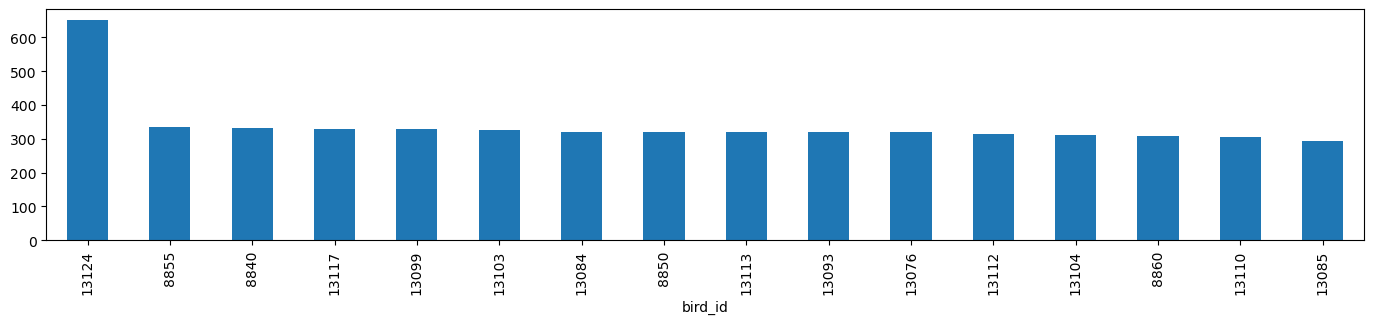

In [16]:
# How many records per unique id?
df["bird_id"].value_counts().plot(kind="bar", figsize=(17, 3))

In [17]:
# Convert to movingpandas
this_bird_id = 13124        
traj = mpd.Trajectory(gdf_subset, this_bird_id, traj_id_col='bird_id', t='timestamp_datetime')
traj.add_speed(overwrite=True)
print(traj.df.describe())

       bird_id    longitude     latitude         speed
count   5143.0  5143.000000  5143.000000   5143.000000
mean   13124.0   -24.089223    58.105461   1732.979659
std        0.0    31.794726    11.271527   3431.328910
min    13124.0   -67.857930    33.000180      0.036196
25%    13124.0   -45.977780    49.995735    229.193439
50%    13124.0   -36.961460    53.544960    536.951902
75%    13124.0   -16.671230    68.127885   1557.469594
max    13124.0    74.133590    82.775130  39465.319091


<Axes: >

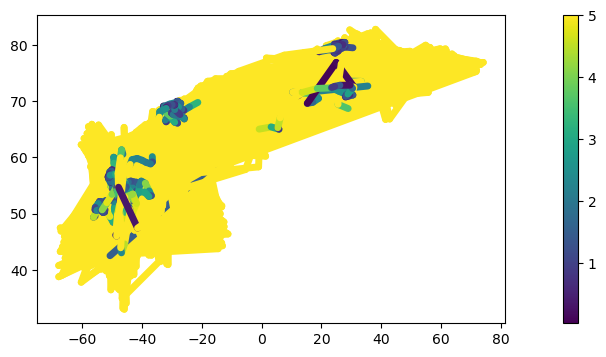

In [18]:
# Plot speed
traj.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True, vmax=5)

In [24]:
# Try trajectory collection
tc = mpd.TrajectoryCollection(
    gdf_subset, "bird_id", t='timestamp_datetime')
tc


TrajectoryCollection with 16 trajectories

In [27]:
tc.add_speed(overwrite=True)

TrajectoryCollection with 16 trajectories

<Axes: >

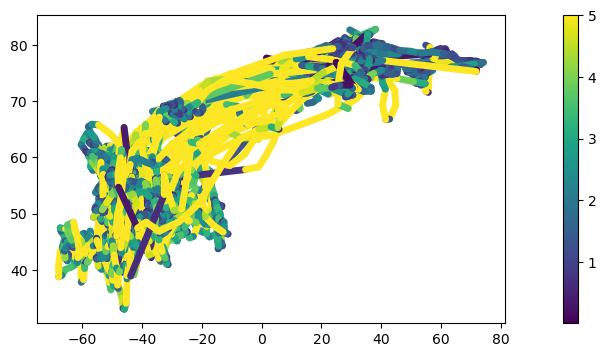

In [33]:
tc.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True, vmax=5)

In [37]:
tc.explore(column="speed", vmax=5)

In [38]:
gdf_with_speed = tc.to_point_gdf()
gdf_with_speed.describe()

,bird_id,longitude,latitude,speed
count,5437.000000,5437.000000,5437.000000,5437.000000
mean,12089.905463,-24.479001,57.976426,2.534417
std,1812.116404,31.567430,11.227004,2.228680
min,8840.000000,-67.857930,33.000180,0.011245
25%,13076.000000,-46.098470,49.957490,1.125792
50%,13099.000000,-37.204980,53.483470,1.936567
75%,13112.000000,-18.068460,67.677110,3.159719
max,13124.000000,74.133590,82.775130,24.040992


In [51]:
gdf_stops = gdf_with_speed[gdf_with_speed["speed"]<0.5]

<Axes: >

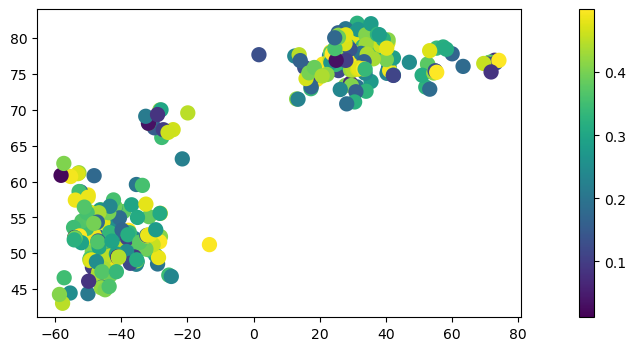

In [52]:
gdf_stops.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)


In [55]:
gdf_transit = gdf_with_speed[gdf_with_speed["speed"].between(10,20)]

<Axes: >

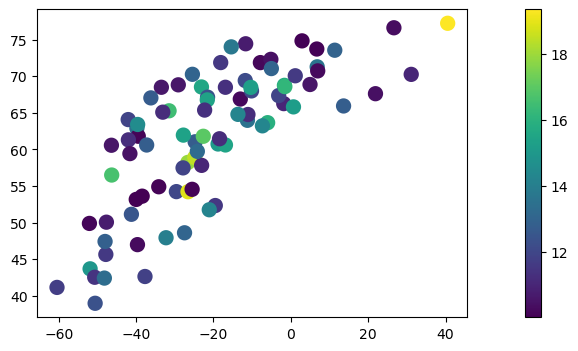

In [56]:
gdf_transit.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True)